In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats

image = '../src/barred_galaxies/strongly_barred/phys_src_01315.fits'
image1 = '../src/barred_galaxies/strongly_barred/phys_src_01315.fits'
image2 = '../src/barred_galaxies/strongly_barred/phys_src_01473.fits'
image3 = '../src/barred_galaxies/strongly_barred/phys_src_01349.fits'
image4 = '../src/barred_galaxies/weakly_barred/phys_src_01156.fits'

file = fits.open(image)
file1 = fits.open(image1)
file2 = fits.open(image2)
file3 = fits.open(image3)
file4 =fits.open(image4)

sci = file["SCI"].data.astype(float)
sci1 = file1["SCI"].data.astype(float)
sci2 = file2["SCI"].data.astype(float)
sci3 = file3["SCI"].data.astype(float)
sci4 = file4["SCI"].data.astype(float)

err = file["ERR"].data.astype(float)
err1 = file1["ERR"].data.astype(float)
err2 = file2["ERR"].data.astype(float)
err3 = file3["ERR"].data.astype(float)
err4 = file4["ERR"].data.astype(float)

mean, sky_median, sky_std = sigma_clipped_stats(sci, sigma=3.0)
mean1, sky_median1, sky_std1 = sigma_clipped_stats(sci1, sigma=3.0)
mean2, sky_median2, sky_std2 = sigma_clipped_stats(sci2, sigma=3.0)
mean3, sky_median3, sky_std3 = sigma_clipped_stats(sci3, sigma=3.0)
mean4, sky_median4, sky_std4 = sigma_clipped_stats(sci4, sigma=3.0)

print(f"sky median = {sky_median:.4f}   sky std = {sky_std:.4f}   peak = {np.nanmax(sci):.4f}")

sky median = 0.0078   sky std = 0.0167   peak = 0.1697


In [2]:
file.info()

Filename: ../src/barred_galaxies/strongly_barred/phys_src_01315.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      44   ()      
  1  SCI           1 ImageHDU         8   (45, 59)   float32   
  2  ERR           1 ImageHDU         8   (45, 59)   float32   
  3  MASKCOMB      1 ImageHDU         8   (45, 59)   uint8   
  4  MASKOTHER     1 ImageHDU         8   (45, 59)   uint8   
  5  SIB01         1 ImageHDU         8   (45, 59)   uint8   


In [3]:
sci

array([[ 0.00568397,  0.00607213,  0.00125063, ..., -0.00337   ,
         0.00285539,  0.00192737],
       [-0.0027648 ,  0.00128773, -0.00087023, ..., -0.00410206,
        -0.0072981 , -0.00540677],
       [-0.00428796, -0.00179225, -0.00193068, ..., -0.00623186,
        -0.00934964, -0.00371044],
       ...,
       [ 0.00322108,  0.00998024,  0.01067794, ...,  0.00188305,
        -0.00059713, -0.00044001],
       [ 0.010054  ,  0.01216922,  0.00644024, ...,  0.00084418,
         0.00082486,  0.00230536],
       [ 0.00740158,  0.00640545,  0.00151465, ...,  0.00207244,
         0.00482381,  0.01104552]], shape=(59, 45))

In [4]:
from astropy.convolution import convolve
from photutils.segmentation import make_2dgaussian_kernel
from scipy import ndimage
from matplotlib.patches import Ellipse

# Gentle smoothing (preserves bar ends) used for the mask & fit
kernel_light = make_2dgaussian_kernel(1.5, size=5)

conv = convolve(sci, kernel_light)
conv1 = convolve(sci1, kernel_light)
conv2 = convolve(sci2, kernel_light)
conv3 = convolve(sci3, kernel_light)
conv4 = convolve(sci4, kernel_light)

# Sky stats computed on the smoothed image (self-consistent subtraction)
_, sky_median_conv, sky_std_conv = sigma_clipped_stats(conv, sigma=3.0)
_, sky_median_conv1, sky_std_conv1 = sigma_clipped_stats(conv1, sigma=3.0)
_, sky_median_conv2, sky_std_conv2 = sigma_clipped_stats(conv2, sigma=3.0)
_, sky_median_conv3, sky_std_conv3 = sigma_clipped_stats(conv3, sigma=3.0)
_, sky_median_conv4, sky_std_conv4 = sigma_clipped_stats(conv4, sigma=3.0)

conv_sub = conv - sky_median_conv
conv_sub1 = conv1 - sky_median_conv1
conv_sub2 = conv2 - sky_median_conv2
conv_sub3 = conv3 - sky_median_conv3
conv_sub4 = conv4 - sky_median_conv4

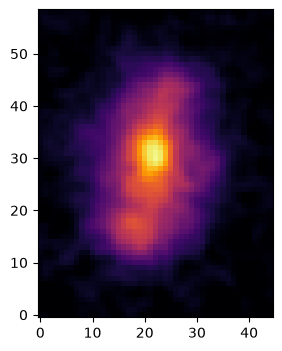

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(conv, origin="lower", cmap="inferno", vmin=0, vmax=sci.max())
plt.show()

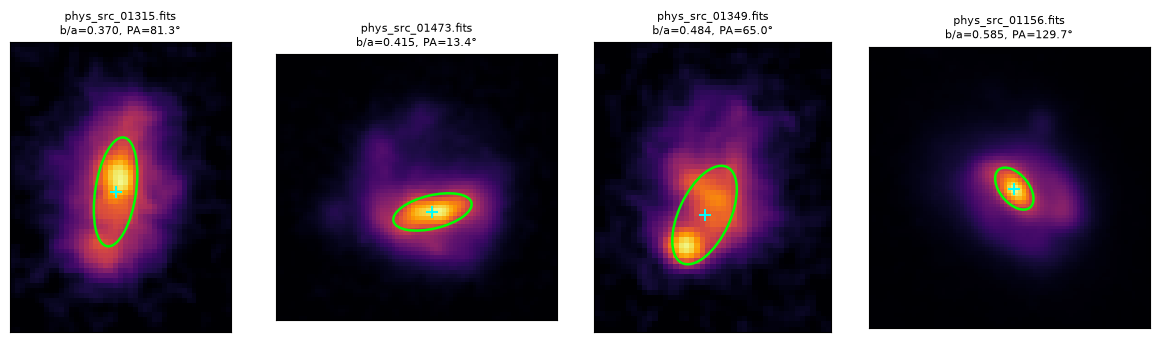

In [12]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.ndimage import (
    binary_closing,
    generate_binary_structure,
    label as nd_label,
    center_of_mass,
    sum as nd_sum,
)

# The notebook's four cutouts are separate galaxies, so fit each one separately.
galaxies = [
    (image1, sci1, conv1, conv_sub1, sky_std_conv1),
    (image2, sci2, conv2, conv_sub2, sky_std_conv2),
    (image3, sci3, conv3, conv_sub3, sky_std_conv3),
    (image4, sci4, conv4, conv_sub4, sky_std_conv4),
]

structure = generate_binary_structure(2, 2)  # 8-connectivity


def fit_moment_ellipse(conv_sub_image, sky_std):
    """Reproduce the notebook's threshold mask and weighted moment ellipse."""
    peak = np.nanmax(conv_sub_image)
    if not np.isfinite(peak) or peak <= 0:
        return None

    threshold = max(3.0 * float(sky_std), 0.53 * float(peak))
    binary = conv_sub_image > threshold
    binary = binary_closing(binary, structure=structure, iterations=1)

    labels, n_labels = nd_label(binary, structure=structure)
    if n_labels == 0:
        return None

    # Keep the largest connected region and nearby small regions.
    if n_labels > 1:
        sizes = nd_sum(binary, labels, range(1, n_labels + 1))
        largest = int(np.argmax(sizes)) + 1
        cy, cx = center_of_mass(binary, labels, largest)
        keep_radius = 1.5 * np.sqrt(sizes[largest - 1] / np.pi)

        keep = [largest]
        for label_id in range(1, n_labels + 1):
            if label_id == largest or sizes[label_id - 1] < 3:
                continue

            yi, xi = center_of_mass(binary, labels, label_id)
            if np.hypot(yi - cy, xi - cx) < keep_radius:
                keep.append(label_id)

        binary = np.isin(labels, keep)

    n_mask_pix = int(binary.sum())
    if n_mask_pix == 0:
        return None

    r_eq = float(np.sqrt(n_mask_pix / np.pi))
    if r_eq < 4.0:
        return None

    ys, xs = np.where(binary)
    weights = np.clip(conv_sub_image[binary], 0.0, None)
    total_weight = float(weights.sum())

    if not np.isfinite(total_weight) or total_weight <= 0:
        return None

    x_center = float((weights * xs).sum() / total_weight)
    y_center = float((weights * ys).sum() / total_weight)

    dx = xs - x_center
    dy = ys - y_center

    mu_xx = float((weights * dx * dx).sum() / total_weight)
    mu_yy = float((weights * dy * dy).sum() / total_weight)
    mu_xy = float((weights * dx * dy).sum() / total_weight)

    covariance = np.array([
        [mu_xx, mu_xy],
        [mu_xy, mu_yy],
    ])
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    if eigenvalues[1] <= 0:
        return None

    # Shape and position angle from the weighted moments.
    q = float(np.sqrt(max(eigenvalues[0], 0.0) / eigenvalues[1]))
    if not np.isfinite(q) or q <= 0:
        return None

    # Set the ellipse size from the mask area, as in the later notebook cell.
    semi_major = r_eq / np.sqrt(q)
    semi_minor = r_eq * np.sqrt(q)

    theta = np.arctan2(eigenvectors[1, -1], eigenvectors[0, -1])
    if semi_major < semi_minor:
        semi_major, semi_minor = semi_minor, semi_major
        theta += np.pi / 2

    angle_deg = float(np.degrees(theta) % 180.0)

    return {
        "x": x_center,
        "y": y_center,
        "a": semi_major,
        "b": semi_minor,
        "q": float(semi_minor / semi_major),
        "angle": angle_deg,
        "n_pix": n_mask_pix,
        "r_eq": r_eq,
    }


fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))

for ax, (image_path, sci_image, conv_image, conv_sub_image, sky_std) in zip(
    axes, galaxies
):
    fit = fit_moment_ellipse(conv_sub_image, sky_std)

    vmax = float(np.nanmax(sci_image))
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = float(np.nanmax(conv_image))
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0

    ax.imshow(
        conv_image,
        origin="lower",
        cmap="inferno",
        vmin=0,
        vmax=vmax,
        interpolation="nearest",
    )

    if fit is None:
        ax.set_title(f"{Path(image_path).name}\nNo ellipse fit")
    else:
        ax.add_patch(
            Ellipse(
                (fit["x"], fit["y"]),
                width=2 * fit["a"],
                height=2 * fit["b"],
                angle=fit["angle"],
                edgecolor="lime",
                facecolor="none",
                linewidth=1.8,
            )
        )
        ax.plot(
            fit["x"],
            fit["y"],
            "+",
            color="cyan",
            markersize=9,
            markeredgewidth=1.4,
        )
        ax.set_title(
            f"{Path(image_path).name}\n"
            f"b/a={fit['q']:.3f}, PA={fit['angle']:.1f}°",
            fontsize=8,
        )

    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
plt.show()

In [7]:
# ============================================================
#  Triage: is this galaxy a suspected barred spiral?
# ============================================================
from scipy.ndimage import (
    binary_closing, generate_binary_structure, label as nd_label,
    center_of_mass, sum as nd_sum,
)

# --- 1. Noise-aware threshold ------------------------------------------------
# sky_std_conv was computed in cell [5] on the smoothed image.
peak_conv = np.nanmax(conv_sub)
thresh = np.maximum(3.0 * sky_std_conv, 0.53 * peak_conv)
binary = conv_sub > thresh

# --- 2. Close small gaps (dust lanes, bad pixels) ----------------------------
struct = generate_binary_structure(2, 2)          # 8-connectivity
binary = binary_closing(binary, structure=struct, iterations=1)

# --- 3. Keep largest blob plus any nearby companions -------------------------
labels, n = nd_label(binary, structure=struct)

if n == 0:
    print("SKIP: no pixels above threshold")
    suspected_barred = False
    n_mask_pix = 0
    r_eq = 0.0
    x_c = y_c = np.nan
    a_fit = b_fit = q = angle_deg = np.nan
else:
    if n > 1:
        sizes = nd_sum(binary, labels, range(1, n + 1))
        largest = int(np.argmax(sizes)) + 1
        cy, cx = center_of_mass(binary, labels, largest)
        r_keep = 1.5 * np.sqrt(sizes[largest - 1] / np.pi)
        keep = [largest]
        for i in range(1, n + 1):
            if i == largest or sizes[i - 1] < 3:
                continue
            yi, xi = center_of_mass(binary, labels, i)
            if np.hypot(yi - cy, xi - cx) < r_keep:
                keep.append(i)
        binary = np.isin(labels, keep)

    n_mask_pix = int(binary.sum())
    r_eq = float(np.sqrt(n_mask_pix / np.pi))

    # --- 4. Minimum-size gate ------------------------------------------------
    MIN_R_EQ = 4.0        # ~PSF FWHM; tune to your data
    if r_eq < MIN_R_EQ:
        print(f"SKIP: mask too small (r_eq = {r_eq:.2f} px)")
        suspected_barred = False
        x_c = y_c = np.nan
        a_fit = b_fit = q = angle_deg = np.nan
    else:
        # --- 5. S/N-weighted moment-of-inertia ellipse -----------------------
        ys_m, xs_m = np.where(binary)
        w = np.clip(conv_sub[binary], 0.0, None)     # flux weight, drop negatives
        W = w.sum()

        if W <= 0:
            print("SKIP: non-positive total weight")
            suspected_barred = False
            x_c = y_c = np.nan
            a_fit = b_fit = q = angle_deg = np.nan
        else:
            x_c = float((w * xs_m).sum() / W)
            y_c = float((w * ys_m).sum() / W)
            dx = xs_m - x_c
            dy = ys_m - y_c
            mu_xx = float((w * dx * dx).sum() / W)
            mu_yy = float((w * dy * dy).sum() / W)
            mu_xy = float((w * dx * dy).sum() / W)

            cov = np.array([[mu_xx, mu_xy], [mu_xy, mu_yy]])
            eigvals, eigvecs = np.linalg.eigh(cov)   # ascending

            # Shape from eigenvalues (scale-free), size from the mask AREA.
            # This makes a_fit*b_fit == r_eq**2 and removes the flux-weighting bias.
            q_axis = float(np.sqrt(eigvals[0] / eigvals[1]))   # b/a, in (0, 1]
            a_fit = r_eq / np.sqrt(q_axis)
            b_fit = r_eq * np.sqrt(q_axis)
            theta = np.arctan2(eigvecs[1, -1], eigvecs[0, -1])

            if a_fit < b_fit:
                a_fit, b_fit = b_fit, a_fit
                theta += np.pi / 2
            angle_deg = float(np.degrees(theta) % 180.0)
            q = float(b_fit / a_fit)

            # --- 6. Triage decision ------------------------------------------
            cond_elong      = q < 0.60
            cond_not_edgeon = q > 0.25
            cond_size       = n_mask_pix >= 40
            cond_resolved   = a_fit >= 3.0

            suspected_barred = (
                cond_elong and cond_not_edgeon and cond_size and cond_resolved
            )

            # --- 7. Log ------------------------------------------------------
            print(f"  q = b/a      = {q:.3f}")
            print(f"  a = {a_fit:.2f} px, b = {b_fit:.2f} px, PA = {angle_deg:.1f} deg")
            print(f"  n_mask_pix   = {n_mask_pix}, r_eq = {r_eq:.2f} px")
            print(f"  cond: elong={cond_elong}, not_edgeon={cond_not_edgeon}, "
                  f"size={cond_size}, resolved={cond_resolved}")
            print(f"  >>> suspected barred: {suspected_barred}")

# --- 8. Masked image for optional visualization ------------------------------
mask = binary if n_mask_pix > 0 else np.zeros_like(binary, dtype=bool)
clustered = conv_sub.astype(float).copy()
clustered[~mask] = np.nan

  q = b/a      = 0.370
  a = 11.20 px, b = 4.15 px, PA = 81.3 deg
  n_mask_pix   = 146, r_eq = 6.82 px
  cond: elong=True, not_edgeon=True, size=True, resolved=True
  >>> suspected barred: True


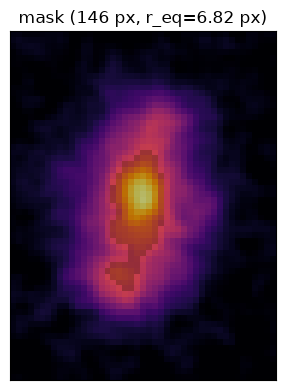

In [8]:
# --- Visualization: smoothed image + mask overlay ----------------------------
if n_mask_pix == 0:
    print("Nothing to plot: empty mask.")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.imshow(conv, origin="lower", cmap="inferno",
              vmin=0, vmax=sci.max())
    ax.imshow(np.where(mask, 1, np.nan), origin="lower",
              cmap="grey", alpha=0.25)
    ax.set_title(f"mask ({n_mask_pix} px, r_eq={r_eq:.2f} px)")
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

center          : (21.01, 28.05) px
semi-major a    : 11.20 px
semi-minor b    : 4.15 px
axis ratio b/a  : 0.370
PA (from +x)    : 81.34 deg


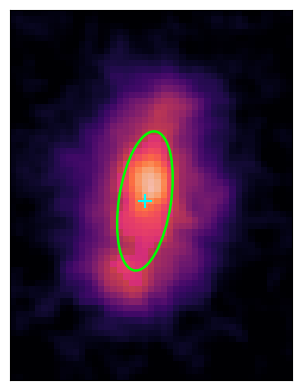

In [9]:
# --- Visualization: fitted moment ellipse overlay ----------------------------
if np.isnan(a_fit):
    print("No ellipse to plot (triage skipped or failed).")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.imshow(conv, origin="lower", cmap="inferno",
              vmin=0, vmax=sci.max())
    ax.imshow(np.where(mask, 1, np.nan), origin="lower",
              cmap="spring", alpha=0.25)

    ax.add_patch(Ellipse((x_c, y_c), 2 * a_fit, 2 * b_fit,
                         angle=angle_deg,
                         edgecolor="lime", facecolor="none", linewidth=1.8))
    ax.plot(x_c, y_c, "+", color="cyan",
            markersize=10, markeredgewidth=1.5)

    print(f"center          : ({x_c:.2f}, {y_c:.2f}) px")
    print(f"semi-major a    : {a_fit:.2f} px")
    print(f"semi-minor b    : {b_fit:.2f} px")
    print(f"axis ratio b/a  : {q:.3f}")
    print(f"PA (from +x)    : {angle_deg:.2f} deg")

    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()